In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression, LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler


In [51]:
train_df = pd.read_csv("KDDTest+.csv",header=None)
test_df = pd.read_csv("KDDTrain+.csv",header=None)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (22543, 43)
Test shape: (125973, 43)


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [52]:
label_col = 41

train_df[label_col] = train_df[label_col].astype(str).str.strip().str.lower()
test_df[label_col]  = test_df[label_col].astype(str).str.strip().str.lower()

In [53]:
train_df["attack_binary"] = (train_df[label_col] != "normal").astype(int)
test_df["attack_binary"]  = (test_df[label_col] != "normal").astype(int)


In [54]:
print(train_df["attack_binary"].value_counts())
print(test_df["attack_binary"].value_counts())


attack_binary
1    12833
0     9710
Name: count, dtype: int64
attack_binary
0    67343
1    58630
Name: count, dtype: int64


In [55]:
X_train = train_df.drop(columns=[label_col, "attack_binary"])
y_train = train_df["attack_binary"]

X_test  = test_df.drop(columns=[label_col, "attack_binary"])
y_test  = test_df["attack_binary"]


In [56]:
cat_cols = X_train.select_dtypes(include=['object']).columns
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)


In [57]:
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

extra_cols = set(X_test.columns) - set(X_train.columns)
X_test.drop(columns=extra_cols, inplace=True)

X_test = X_test[X_train.columns]


In [59]:
# Ensure DataFrame form
X_train = pd.DataFrame(X_train)
X_test  = pd.DataFrame(X_test)

# Convert all feature names to string
X_train.columns = X_train.columns.astype(str)
X_test.columns  = X_test.columns.astype(str)

print("Column names fixed! Ready for scaling.")


Column names fixed! Ready for scaling.


In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [68]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree Classifier": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        eval_metric="logloss",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
}


In [69]:
results = {}

for name, model in models.items():
    print(f"{name}")
    print("\n")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Skip classification metrics if regression model
    if name in ["Linear Regression (OLS)", "Gradient Descent (SGD)", "Decision Tree Regressor"]:
        results[name] = {
            "note": "Regression model – classification metrics not applicable"
        }
        continue
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    results[name] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
        "report": report
    }


Logistic Regression


Decision Tree Classifier


Random Forest


Gradient Boosting


XGBoost


KNN


SVM (RBF)




In [70]:
print("\nMODEL RESULTS\n")

for name, metrics in results.items():
    print(name)
    print("-" * len(name))
    
    if "note" in metrics:
        print(metrics["note"])
        print()
        continue
    
    print("Accuracy:", metrics["accuracy"])
    print("Precision:", metrics["precision"])
    print("Recall:", metrics["recall"])
    print("F1-Score:", metrics["f1"])
    print("\nConfusion Matrix:")
    print(metrics["confusion_matrix"])
    print("\nClassification Report:")
    print(metrics["report"])
    print("\n")



MODEL RESULTS

Logistic Regression
-------------------
Accuracy: 0.9320965603740484
Precision: 0.9078115838165353
Recall: 0.9506396042981409
F1-Score: 0.9287321080432573

Confusion Matrix:
[[61683  5660]
 [ 2894 55736]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     67343
           1       0.91      0.95      0.93     58630

    accuracy                           0.93    125973
   macro avg       0.93      0.93      0.93    125973
weighted avg       0.93      0.93      0.93    125973



Decision Tree Classifier
------------------------
Accuracy: 0.9816547990442397
Precision: 0.9792372232338876
Recall: 0.9813917789527545
F1-Score: 0.9803133172614129

Confusion Matrix:
[[66123  1220]
 [ 1091 57539]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     67343
           1       0.98      0.98      0.98     58630

    accuracy           

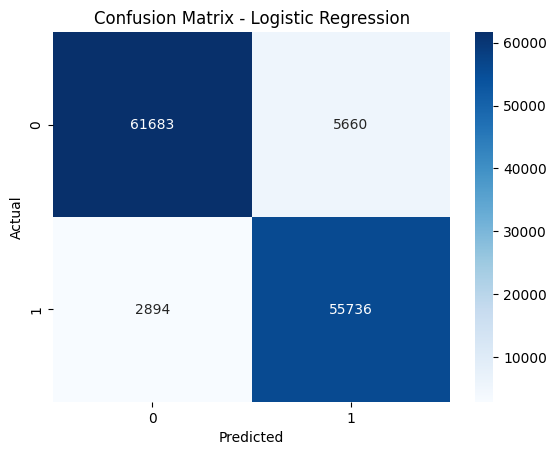

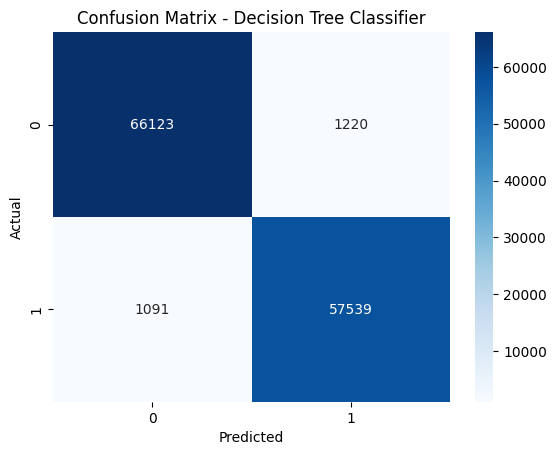

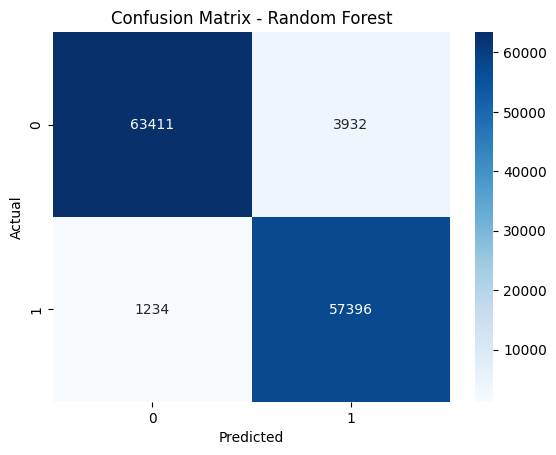

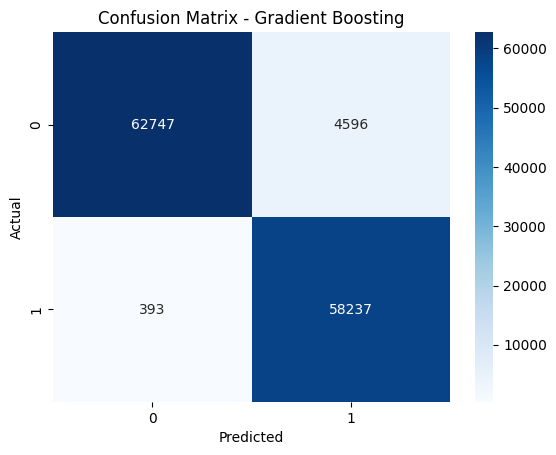

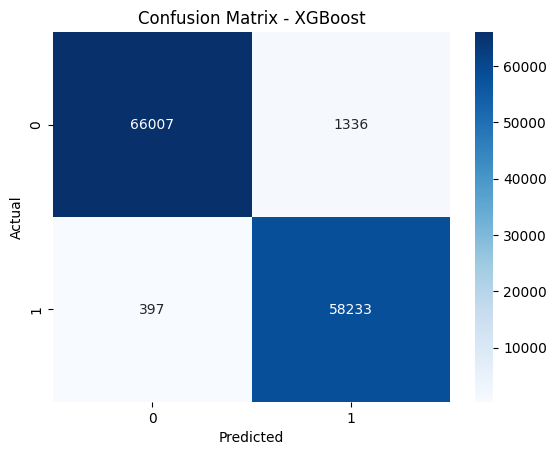

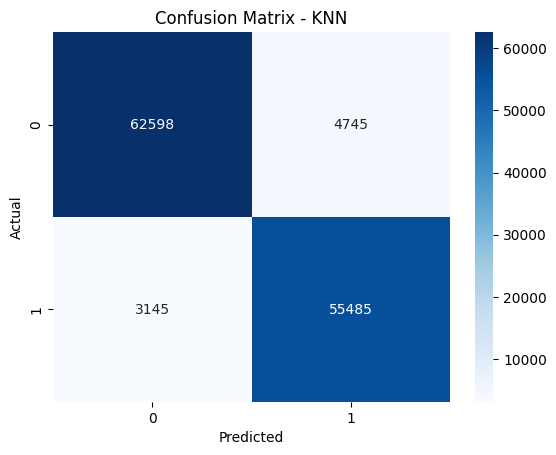

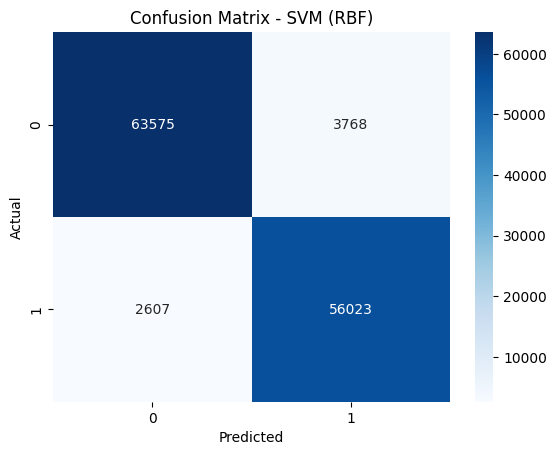

In [71]:
def plot_cm(name):
    cm = results[name]["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

for name in results:
    if "confusion_matrix" in results[name]:
        plot_cm(name)


In [72]:
with open("model_results_binary.txt", "w") as f:
    f.write("MODELWISE SUMMARY (Binary Classification)\n")
    f.write("="*60 + "\n\n")

    for name, r in results.items():
        f.write(f"MODEL: {name}\n")
        f.write("="*40 + "\n")
        if "accuracy" in r:
            f.write(f"Accuracy: {r['accuracy']:.4f}\n")
            f.write(f"Precision: {r['precision']:.4f}\n")
            f.write(f"Recall: {r['recall']:.4f}\n")
            f.write(f"F1 Score: {r['f1']:.4f}\n\n")
            f.write("Confusion Matrix:\n")
            f.write(str(r["confusion_matrix"]) + "\n\n")
            f.write("Classification Report:\n")
            f.write(r["report"] + "\n\n")
        else:
            f.write("Regression model — metrics not applicable.\n\n")
